In [ ]:


import numpy as np

np.set_printoptions(suppress=True, precision=6)



A_H2 = np.array([
    [1.12854, 0.0,     0.0,     0.03593],
    [0.0,     1.44616, 0.08368, 0.0],
    [0.0,     0.08368, 1.44616, 0.0],
    [0.03593, 0.0,     0.0,     1.94607]
])

b_H2 = np.array([-0.2, -0.15, -0.15, -0.1])



A_LiH = np.array([
    [0.500000, -0.051643,  0.051643,  0.011732],
    [-0.051643, 0.648716, -0.011732,  0.000000],
    [0.051643, -0.011732, 0.662297,  0.000000],
    [0.011732, 0.000000,  0.000000, 1.211248]
])

b_LiH = np.array([-0.2, -0.15, -0.15, -0.1])


def print_matrix_info(name, A, b):

    print("="*60)
    print(f"{name} SYSTEM")
    print("="*60)

    print("\nA matrix:")
    print(A)

    print("\nb vector:")
    print(b)

    print("\nSymmetric:", np.allclose(A, A.T))

    eigvals = np.linalg.eigvalsh(A)

    print("\nEigenvalues:")
    print(np.round(eigvals, 6))

    print("\nCondition number:")
    print(np.linalg.cond(A))

    x_classical = np.linalg.solve(A, -b)

    print("\nClassical solution x = -A^{-1}b:")
    print(np.round(x_classical, 6))

    E_corr = b @ x_classical

    print("\nClassical E_corr:")
    print(E_corr)

    print("\nMatrix dimension:")
    print(A.shape)

    print("\nRequired system qubits:")
    print(int(np.log2(A.shape[0])))

    print("\n")


print_matrix_info("H2", A_H2, b_H2)

print_matrix_info("LiH", A_LiH, b_LiH)

H2 SYSTEM

A matrix:
[[1.12854 0.      0.      0.03593]
 [0.      1.44616 0.08368 0.     ]
 [0.      0.08368 1.44616 0.     ]
 [0.03593 0.      0.      1.94607]]

b vector:
[-0.2  -0.15 -0.15 -0.1 ]

Symmetric: True

Eigenvalues:
[1.126964 1.36248  1.52984  1.947646]

Condition number:
1.728223953023889

Classical solution x = -A^{-1}b:
[0.175687 0.098049 0.098049 0.048142]

Classical E_corr:
-0.06936651345557258

Matrix dimension:
(4, 4)

Required system qubits:
2


LiH SYSTEM

A matrix:
[[ 0.5      -0.051643  0.051643  0.011732]
 [-0.051643  0.648716 -0.011732  0.      ]
 [ 0.051643 -0.011732  0.662297  0.      ]
 [ 0.011732  0.        0.        1.211248]]

b vector:
[-0.2  -0.15 -0.15 -0.1 ]

Symmetric: True

Eigenvalues:
[0.472399 0.643024 0.695393 1.211444]

Condition number:
2.5644488898767865

Classical solution x = -A^{-1}b:
[0.405123 0.267087 0.199626 0.078636]

Classical E_corr:
-0.1588950787219547

Matrix dimension:
(4, 4)

Required system qubits:
2




In [ ]:

import numpy as np
import itertools

from scipy.linalg import expm

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT, RYGate, UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit_aer import Aer

from collections import Counter

np.set_printoptions(suppress=True, precision=6)


def run_hhl(A, b, n_clock=5, t=5, C=0.2, shots=4096):

  

    n_state = int(np.log2(A.shape[0]))
    n_anc   = 1

    b_norm = b / np.linalg.norm(b)

    backend = Aer.get_backend('qasm_simulator')



    x_classical = np.linalg.solve(A, -b)

    E_classical = b @ x_classical

   

    cU_list = []

    for k in range(n_clock):

        U = expm(1j * A * (2**k) * t)

        gate = UnitaryGate(U, label=f"U{2**k}")

        cU = gate.control()

        cU_list.append(cU)


    clock_qubits = list(range(n_clock))

    state_qubits = list(
        range(n_clock, n_clock+n_state)
    )

    ancilla = n_clock + n_state


    qc = QuantumCircuit(
        n_clock + n_state + n_anc,
        n_clock + 1 + n_state
    )


    qc.initialize(b_norm, state_qubits)


    for q in clock_qubits:
        qc.h(q)

   

    for k in range(n_clock):

        qc.append(
            cU_list[k],
            [clock_qubits[k]] + state_qubits
        )



    iqft = QFT(
        n_clock,
        inverse=True,
        do_swaps=True
    )

    qc.append(iqft, clock_qubits)

  

    for bits in itertools.product([0,1], repeat=n_clock):

   

        k = int(
            "".join(map(str, bits[::-1])),
            2
        )

        if k == 0:
            continue

       

        theta = k / (2**n_clock)

        lam = 2*np.pi*theta/t

        if lam == 0:
            continue

    

        angle = 2*np.arcsin(
            min(1, C/lam)
        )

     

        controls = []

        for i,bit in enumerate(bits):

            if bit == 0:
                qc.x(clock_qubits[i])

            controls.append(clock_qubits[i])


        qc.append(
            RYGate(angle).control(n_clock),
            controls + [ancilla]
        )


        for i,bit in enumerate(bits):

            if bit == 0:
                qc.x(clock_qubits[i])

    

    qc.append(
        QFT(
            n_clock,
            inverse=False,
            do_swaps=True
        ),
        clock_qubits
    )

    for k in reversed(range(n_clock)):

        qc.append(
            cU_list[k],
            [clock_qubits[k]] + state_qubits
        )

    for q in clock_qubits:
        qc.h(q)


    qc.measure(ancilla, n_clock)

    qc.measure(
        state_qubits,
        range(n_clock+1, n_clock+1+n_state)
    )


    qc_t = transpile(qc, backend)

    result = backend.run(
        qc_t,
        shots=shots
    ).result()

    counts = result.get_counts()

   

    state_counts = Counter()

    for bitstring,count in counts.items():

        bits = bitstring[::-1]

        anc = bits[n_clock]

        if anc == '1':

            state = bits[
                n_clock+1 :
                n_clock+1+n_state
            ]

            state_counts[state] += count



    total = sum(state_counts.values())

    probs = {
        k:v/total for k,v in state_counts.items()
    }

    amps = {
        k:np.sqrt(v) for k,v in probs.items()
    }

    x_quantum = np.array([

        amps.get(
            format(i, f'0{n_state}b'),
            0
        )

        for i in range(2**n_state)

    ])

    x_quantum = (
        x_quantum /
        np.linalg.norm(x_quantum)
    )

  

    b_norm_vec = b / np.linalg.norm(b)

    overlap = np.dot(
        b_norm_vec,
        x_quantum
    )

    x_classical_norm = (
        x_classical /
        np.linalg.norm(x_classical)
    )

    overlap_classical = np.dot(
        b_norm_vec,
        x_classical_norm
    )

    scale = (
        E_classical /
        overlap_classical
    )

    E_est = scale * overlap



    print("="*60)
    print("HHL RESULTS")
    print("="*60)

    print("\nQuantum x:")
    print(np.round(x_quantum,6))

    print("\nEstimated E_corr:")
    print(E_est)

    print("\nClassical E_corr:")
    print(E_classical)

    print("\nCircuit depth:")
    print(qc.depth())


    return {
        "qc": qc,
        "counts": counts,
        "x_quantum": x_quantum,
        "E_est": E_est,
        "E_classical": E_classical
    }

C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_9212\3757578197.py:109: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(
C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_9212\3757578197.py:190: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(


HHL RESULTS

Quantum x:
[0.22101  0.68022  0.67432  0.183706]

Estimated E_corr:
-0.06084022425047782

Classical E_corr:
-0.06936651345557258

Circuit depth:
101


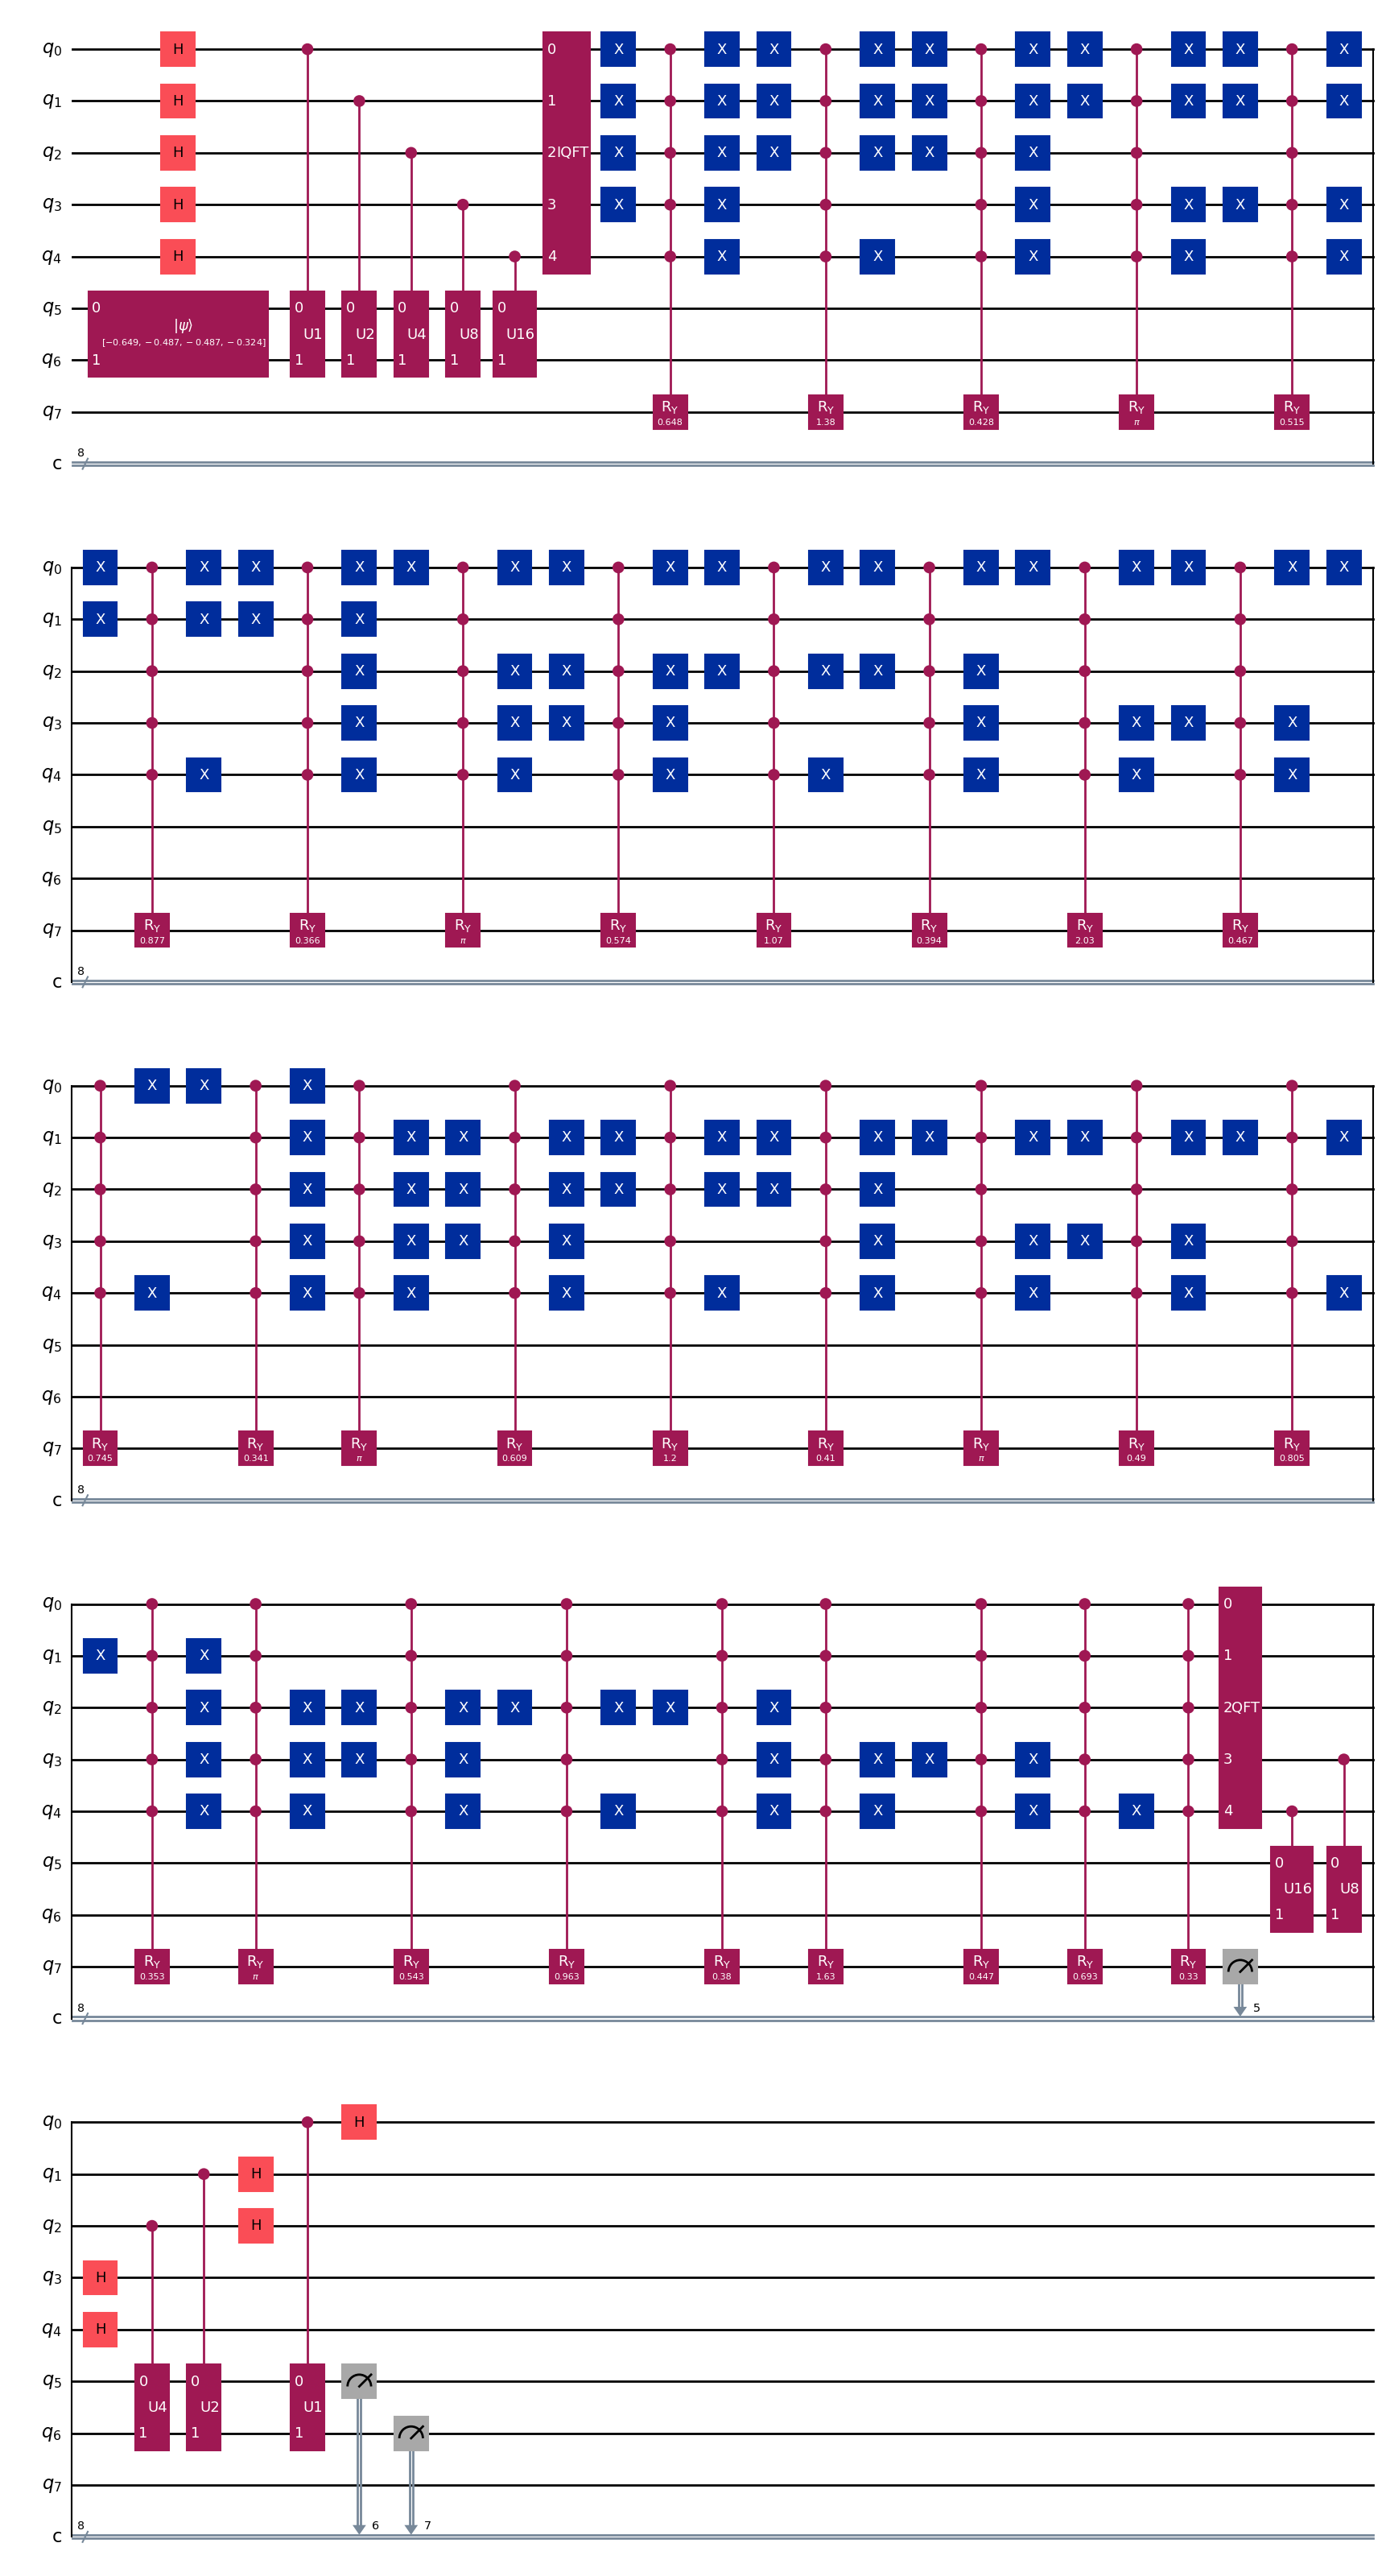

In [20]:
results = run_hhl(A_H2, b_H2)

results["qc"].draw(
    'mpl'
    
)

## Lite

In [ ]:


import numpy as np
import itertools
import matplotlib.pyplot as plt

from collections import Counter
from scipy.linalg import expm

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT, RYGate, UnitaryGate

from qiskit_aer import Aer
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error
)

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2
)

from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)

np.set_printoptions(
    suppress=True,
    precision=6
)



sim_backend = Aer.get_backend('qasm_simulator')



noise_model = NoiseModel()

p1 = 0.001
p2 = 0.01

err1 = depolarizing_error(p1, 1)
err2 = depolarizing_error(p2, 2)

noise_model.add_all_qubit_quantum_error(
    err1,
    ['u1', 'u2', 'u3', 'h', 'x', 'ry']
)

noise_model.add_all_qubit_quantum_error(
    err2,
    ['cx']
)

print("Noise model ready.")



service = QiskitRuntimeService(
    channel="ibm_quantum_platform"
)

hw_backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=8
)

print("Hardware backend:", hw_backend.name)

Noise model ready.


qiskit_runtime_service.__init__:WARNING:2026-05-15 12:05:35,387: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-15 12:05:36,533: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-15 12:05:39,867: Using instance: open-instance, plan: open


Hardware backend: ibm_fez


In [ ]:

A_H2 = np.array([
    [1.12854, 0.0,     0.0,     0.03593],
    [0.0,     1.44616, 0.08368, 0.0],
    [0.0,     0.08368, 1.44616, 0.0],
    [0.03593, 0.0,     0.0,     1.94607]
])

b_H2 = np.array([
    -0.2,
    -0.15,
    -0.15,
    -0.1
])



A_LiH = np.array([
    [0.500000, -0.051643,  0.051643,  0.011732],
    [-0.051643, 0.648716, -0.011732,  0.000000],
    [0.051643, -0.011732, 0.662297,  0.000000],
    [0.011732, 0.000000,  0.000000, 1.211248]
])

b_LiH = np.array([
    -0.2,
    -0.15,
    -0.15,
    -0.1
])



def print_matrix_info(name, A, b):

    eigvals = np.linalg.eigvalsh(A)

    x_cl = np.linalg.solve(A, -b)

    E_cl = float(b @ x_cl)

    print("="*60)
    print(name)
    print("="*60)

    print("Eigenvalues:")
    print(np.round(eigvals, 6))

    print("\nCondition number:")
    print(np.linalg.cond(A))

    print("\nClassical E_corr:")
    print(E_cl)

    print("\n")

print_matrix_info("H2", A_H2, b_H2)
print_matrix_info("LiH", A_LiH, b_LiH)

H2
Eigenvalues:
[1.126964 1.36248  1.52984  1.947646]

Condition number:
1.728223953023889

Classical E_corr:
-0.06936651345557258


LiH
Eigenvalues:
[0.472399 0.643024 0.695393 1.211444]

Condition number:
2.5644488898767865

Classical E_corr:
-0.1588950787219547




In [ ]:


def build_controlled_unitaries(
    A,
    n_clock=5,
    t=5
):

    cU_list = []

    for k in range(n_clock):

        U = expm(
            1j * A * (2**k) * t
        )

        gate = UnitaryGate(
            U,
            label=f"U{2**k}"
        )

        cU_list.append(
            gate.control()
        )

    return cU_list

In [ ]:


def get_qpe_statistics(
    A,
    b,
    cU_list,
    backend,
    n_clock=5,
    shots=4096
):

    n_state = int(np.log2(A.shape[0]))

    b_norm = b / np.linalg.norm(b)

    qc = QuantumCircuit(
        n_clock + n_state,
        n_clock
    )

    state_qubits = list(
        range(n_clock, n_clock+n_state)
    )

    # --------------------------------------------------------
    # Prepare |b>
    # --------------------------------------------------------

    qc.initialize(
        b_norm,
        state_qubits
    )

    # --------------------------------------------------------

    for i in range(n_clock):
        qc.h(i)

    # --------------------------------------------------------

    for i in range(n_clock):

        qc.append(
            cU_list[i],
            [i] + state_qubits
        )

    # --------------------------------------------------------

    qc.append(
        QFT(
            n_clock,
            inverse=True,
            do_swaps=True
        ),
        range(n_clock)
    )

    qc.measure(
        range(n_clock),
        range(n_clock)
    )

    # --------------------------------------------------------

    counts = backend.run(
        transpile(qc, backend),
        shots=shots
    ).result().get_counts()

    total = sum(counts.values())

    qubit_probs = []

    for i in range(n_clock):

        p1 = sum(
            c for bs,c in counts.items()
            if bs[::-1][i]=='1'
        )

        qubit_probs.append(
            p1 / total
        )

    confidence = [
        abs(p - 0.5)
        for p in qubit_probs
    ]

    order = np.argsort(confidence)[::-1]

    print("Per-qubit P(1):",
          np.round(qubit_probs,3))

    print("Fixing order:  ",
          order)

    return qubit_probs, order, confidence

In [ ]:

def build_lite_circuit(
    A,
    b,
    cU_list,
    fixed,
    n_clock=5,
    t=5,
    C=0.2
):

    n_state = int(np.log2(A.shape[0]))

    b_norm = b / np.linalg.norm(b)

    clock_qubits = list(range(n_clock))

    state_qubits = list(
        range(n_clock, n_clock+n_state)
    )

    ancilla = n_clock + n_state

    qc = QuantumCircuit(
        n_clock + n_state + 1,
        1 + n_state
    )



    qc.initialize(
        b_norm,
        state_qubits
    )

   

    for i in clock_qubits:

        if i not in fixed:
            qc.h(i)

        elif fixed[i] == 1:
            qc.x(i)


    for i in clock_qubits:

        if i in fixed and fixed[i] == 0:
            continue

        qc.append(
            cU_list[i],
            [i] + state_qubits
        )

   

    qc.append(
        QFT(
            n_clock,
            inverse=True,
            do_swaps=True
        ),
        clock_qubits
    )

    

    free = [
        i for i in clock_qubits
        if i not in fixed
    ]

    for bits_free in itertools.product(
        [0,1],
        repeat=len(free)
    ):

        bits = [0]*n_clock

        for i,val in fixed.items():
            bits[i] = val

        for j,i in enumerate(free):
            bits[i] = bits_free[j]

        k = int(
            "".join(map(str,bits[::-1])),
            2
        )

        if k == 0:
            continue

        theta = k / (2**n_clock)

        lam = 2*np.pi*theta/t

        if lam == 0:
            continue

        angle = 2*np.arcsin(
            min(1, C/lam)
        )

 

        for i,bv in zip(free,bits_free):

            if bv == 0:
                qc.x(i)

   

        if len(free) > 0:

            qc.append(
                RYGate(angle).control(len(free)),
                free + [ancilla]
            )

        else:

            qc.ry(angle, ancilla)


        for i,bv in zip(free,bits_free):

            if bv == 0:
                qc.x(i)


    qc.append(
        QFT(
            n_clock,
            inverse=False,
            do_swaps=True
        ),
        clock_qubits
    )

    for i in reversed(clock_qubits):

        if i in fixed and fixed[i] == 0:
            continue

        qc.append(
            cU_list[i],
            [i] + state_qubits
        )

    for i in clock_qubits:

        if i not in fixed:
            qc.h(i)

  

    qc.measure(ancilla, 0)

    qc.measure(
        state_qubits,
        range(1,1+n_state)
    )

    return qc

In [ ]:


import time

def get_Ecorr_from_circuit(
    qc,
    A,
    b,
    n_clock,
    backend=None,
    noise_model=None,
    use_runtime=False,
    shots=4096
):

    start = time.time()


    if use_runtime:

        pm = generate_preset_pass_manager(
            optimization_level=1,
            backend=backend
        )

        qc_t = pm.run(qc)

        sampler = SamplerV2(backend)

        job = sampler.run(
            [qc_t],
            shots=shots
        )

        print(f"    Job ID: {job.job_id()}")

        result = job.result()

        counts = result[0].data.c.get_counts()

    else:

        qc_t = transpile(
            qc,
            backend,
            optimization_level=0
        )

        counts = backend.run(
            qc_t,
            shots=shots,
            noise_model=noise_model
        ).result().get_counts()

    runtime = time.time() - start

  

    n_state = int(np.log2(A.shape[0]))

    state_counts = Counter()

    for bs,c in counts.items():

        bits = bs[::-1]

        if bits[0] == '1':

            state = bits[1:1+n_state]

            state_counts[state] += c

    total = sum(state_counts.values())

    if total == 0:

        print("  Warning: no ancilla=1 shots")

        return np.nan, np.nan, runtime


    probs = {
        k:v/total
        for k,v in state_counts.items()
    }

    amps = np.array([

        np.sqrt(
            probs.get(
                format(i,f'0{n_state}b'),
                0
            )
        )

        for i in range(2**n_state)

    ])

    amps /= np.linalg.norm(amps)


    x_cl = np.linalg.solve(A, -b)

    E_cl = float(b @ x_cl)


    b_norm = b / np.linalg.norm(b)

    overlap = np.dot(
        b_norm,
        amps
    )

    x_cl_norm = (
        x_cl /
        np.linalg.norm(x_cl)
    )

    overlap_cl = np.dot(
        b_norm,
        x_cl_norm
    )

    scale = E_cl / overlap_cl

    E_est = scale * overlap

    return E_est, E_cl, runtime

In [ ]:


def run_sweep(
    label,
    A,
    b,
    cU_list,
    qubit_probs,
    order,
    threshold=0.8,
    backend=None,
    noise_model=None,
    use_runtime=False,
    n_clock=5,
    shots=4096
):

    print("\n" + "="*55)
    print(label)
    print("="*55)

    results = []

    for n_f in range(n_clock + 1):

     

        fixed = {}

        for i in order[:n_f]:

            if qubit_probs[i] > threshold:
                fixed[i] = 1

            elif qubit_probs[i] < (1-threshold):
                fixed[i] = 0

        actual_nf = len(fixed)


        qc = build_lite_circuit(
            A,
            b,
            cU_list,
            fixed,
            n_clock=n_clock
        )


        if use_runtime:

            pm = generate_preset_pass_manager(
            optimization_level=1,
            backend=backend
            )

            qc_t = pm.run(qc)

        else:

            qc_t = transpile(
            qc,
            backend,
            optimization_level=1
            )


        depth_transpiled = qc_t.depth()

        gate_counts = qc_t.count_ops()



        if use_runtime:

            entangling_count = (
                gate_counts.get('cz', 0)
                )

            entangling_label = "CZ"

        else:

            entangling_count = gate_counts.get('cx', 0)

            entangling_label = "CX"

        E_est, E_cl, runtime = get_Ecorr_from_circuit(
            qc,
            A,
            b,
            n_clock,
            backend=backend,
            noise_model=noise_model,
            use_runtime=use_runtime,
            shots=shots
        )

    

        pfd = (
            (E_est - E_cl)
            / abs(E_cl)
            * 100
        ) if not np.isnan(E_est) else np.nan

        depth = depth_transpiled

        compression = (
            1 - depth/101
        ) * 100


        results.append(
            (
                n_f,
                actual_nf,
                E_est,
                pfd,
                depth,
                entangling_count,
                compression,
                runtime
            )
        )

        print(
            f"n_f={n_f} "
            f"| fixed={actual_nf} "
            f"| E={E_est:.5f} "
            f"| PFD={pfd:+.2f}% "
            f"| depth={depth} "
            f"| {entangling_label}={entangling_count} "
            f"| runtime={runtime:.2f}s"
            )

    return results



In [ ]:


A = A_H2
b = b_H2



n_clock = 5

cU_list = build_controlled_unitaries(
    A,
    n_clock=n_clock,
    t=5
)


qubit_probs, order, confidence = get_qpe_statistics(
    A,
    b,
    cU_list,
    backend=sim_backend,
    n_clock=n_clock
)


all_results = {}


all_results['noiseless'] = run_sweep(
    'Noiseless Simulator',
    A,
    b,
    cU_list,
    qubit_probs,
    order,
    backend=sim_backend,
    noise_model=None,
    use_runtime=False
)



all_results['noisy'] = run_sweep(
    'Noisy Simulator',
    A,
    b,
    cU_list,
    qubit_probs,
    order,
    backend=sim_backend,
    noise_model=noise_model,
    use_runtime=False
)



all_results['hardware'] = run_sweep(
    'IBM Hardware',
    A,
    b,
    cU_list,
    qubit_probs,
    order,
    backend=hw_backend,
    use_runtime=True,
    shots=2048
)

C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_27456\4213744712.py:53: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(


Per-qubit P(1): [0.83  0.583 0.857 0.406 0.522]
Fixing order:   [2 0 3 1 4]

Noiseless Simulator


C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_27456\912515388.py:72: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(
C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_27456\912515388.py:155: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(


n_f=0 | fixed=0 | E=-0.06208 | PFD=+10.50% | depth=1795 | CX=1320 | runtime=0.99s
n_f=1 | fixed=1 | E=-0.06901 | PFD=+0.51% | depth=687 | CX=464 | runtime=0.59s
n_f=2 | fixed=2 | E=-0.07000 | PFD=-0.92% | depth=278 | CX=128 | runtime=0.23s
n_f=3 | fixed=2 | E=-0.06996 | PFD=-0.85% | depth=278 | CX=128 | runtime=0.25s
n_f=4 | fixed=2 | E=-0.07026 | PFD=-1.28% | depth=278 | CX=128 | runtime=0.21s
n_f=5 | fixed=2 | E=-0.07006 | PFD=-1.00% | depth=278 | CX=128 | runtime=0.21s

Noisy Simulator
n_f=0 | fixed=0 | E=-0.07007 | PFD=-1.01% | depth=1795 | CX=1320 | runtime=51.06s
n_f=1 | fixed=1 | E=-0.07003 | PFD=-0.96% | depth=687 | CX=464 | runtime=22.79s
n_f=2 | fixed=2 | E=-0.06965 | PFD=-0.40% | depth=278 | CX=128 | runtime=7.37s
n_f=3 | fixed=2 | E=-0.06965 | PFD=-0.41% | depth=278 | CX=128 | runtime=7.42s
n_f=4 | fixed=2 | E=-0.06966 | PFD=-0.43% | depth=278 | CX=128 | runtime=7.46s
n_f=5 | fixed=2 | E=-0.06996 | PFD=-0.86% | depth=278 | CX=128 | runtime=7.46s

IBM Hardware
    Job ID: d8

In [ ]:


A = A_LiH
b = b_LiH

print("\n")
print("="*70)
print("RUNNING LiH")
print("="*70)



cU_list = build_controlled_unitaries(
    A,
    n_clock=n_clock,
    t=5
)


qubit_probs, order, confidence = get_qpe_statistics(
    A,
    b,
    cU_list,
    backend=sim_backend,
    n_clock=n_clock
)



all_results_LiH = {}



all_results_LiH['noiseless'] = run_sweep(
    'LiH — Noiseless Simulator',
    A,
    b,
    cU_list,
    qubit_probs,
    order,
    backend=sim_backend,
    noise_model=None,
    use_runtime=False
)



all_results_LiH['noisy'] = run_sweep(
    'LiH — Noisy Simulator',
    A,
    b,
    cU_list,
    qubit_probs,
    order,
    backend=sim_backend,
    noise_model=noise_model,
    use_runtime=False
)


all_results_LiH['hardware'] = run_sweep(
    'LiH — IBM Hardware',
    A,
    b,
    cU_list,
    qubit_probs,
    order,
    backend=hw_backend,
    use_runtime=True,
    shots=2048
)



RUNNING LiH
Per-qubit P(1): [0.261 0.244 0.526 0.522 0.588]
Fixing order:   [1 0 4 2 3]

LiH — Noiseless Simulator


C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_27456\4213744712.py:53: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(
C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_27456\912515388.py:72: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(
C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_27456\912515388.py:155: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, fo

n_f=0 | fixed=0 | E=-0.16160 | PFD=-1.71% | depth=1831 | CX=1340 | runtime=1.25s
n_f=1 | fixed=0 | E=-0.15969 | PFD=-0.50% | depth=1831 | CX=1340 | runtime=1.16s
n_f=2 | fixed=0 | E=-0.16104 | PFD=-1.35% | depth=1831 | CX=1340 | runtime=1.25s
n_f=3 | fixed=0 | E=-0.16048 | PFD=-1.00% | depth=1831 | CX=1340 | runtime=1.16s
n_f=4 | fixed=0 | E=-0.16141 | PFD=-1.58% | depth=1831 | CX=1340 | runtime=1.16s
n_f=5 | fixed=0 | E=-0.16147 | PFD=-1.62% | depth=1831 | CX=1340 | runtime=1.15s

LiH — Noisy Simulator
n_f=0 | fixed=0 | E=-0.16150 | PFD=-1.64% | depth=1831 | CX=1340 | runtime=45.69s
n_f=1 | fixed=0 | E=-0.16086 | PFD=-1.24% | depth=1831 | CX=1340 | runtime=59.23s
n_f=2 | fixed=0 | E=-0.16145 | PFD=-1.61% | depth=1831 | CX=1340 | runtime=55.62s
n_f=3 | fixed=0 | E=-0.16069 | PFD=-1.13% | depth=1831 | CX=1340 | runtime=52.59s
n_f=4 | fixed=0 | E=-0.16104 | PFD=-1.35% | depth=1831 | CX=1340 | runtime=59.15s
n_f=5 | fixed=0 | E=-0.16165 | PFD=-1.74% | depth=1831 | CX=1340 | runtime=59.31s

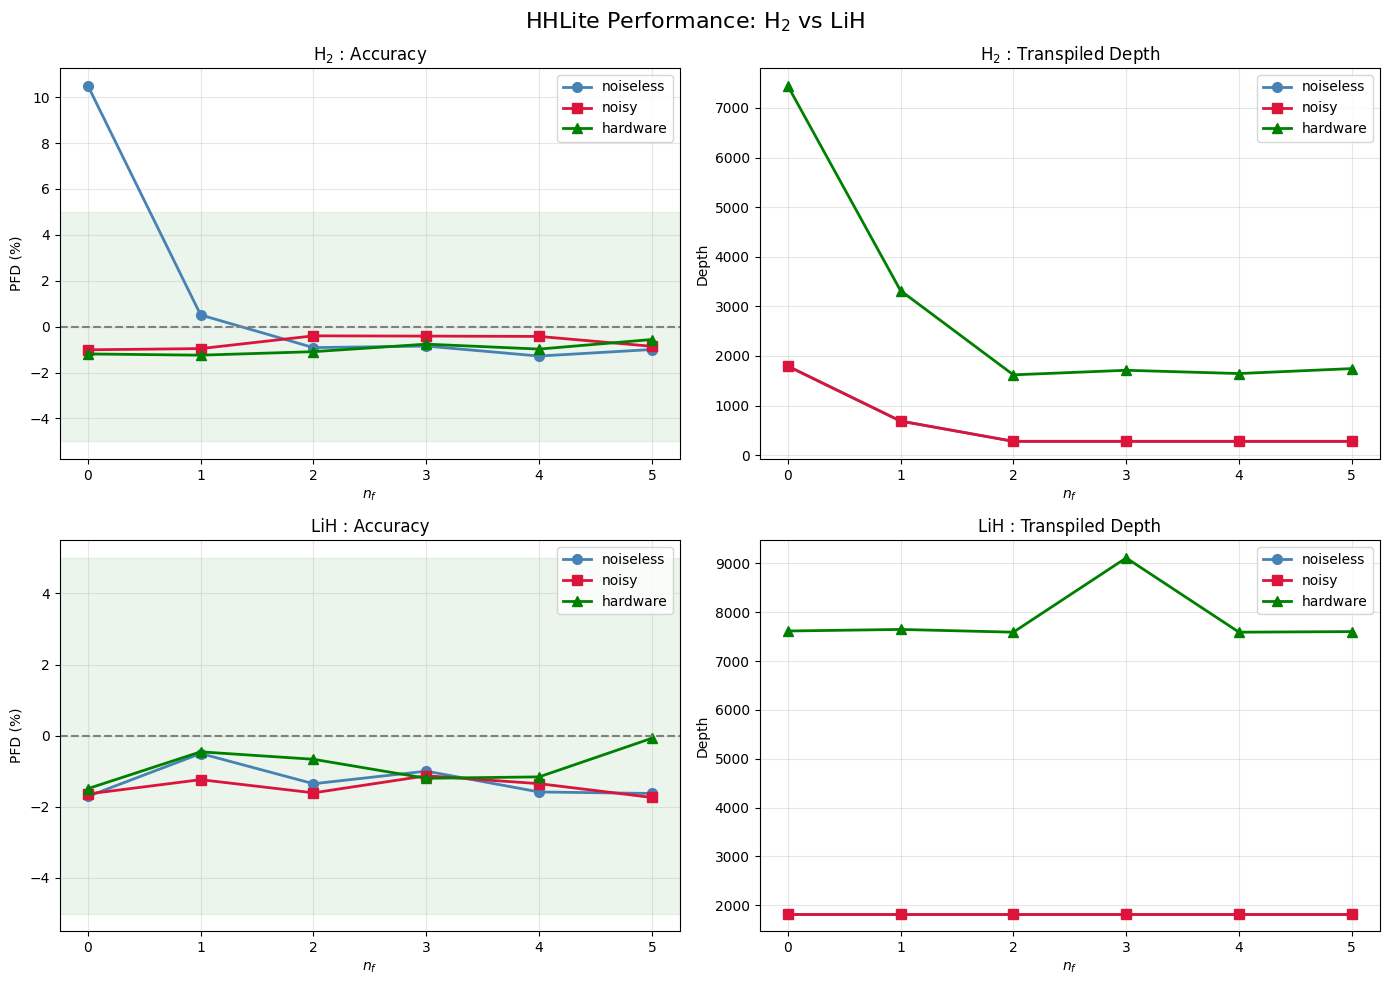

In [ ]:


fig, axes = plt.subplots(
    2, 2,
    figsize=(14,10)
)



colors = {
    'noiseless': 'steelblue',
    'noisy': 'crimson',
    'hardware': 'green'
}

markers = {
    'noiseless': 'o',
    'noisy': 's',
    'hardware': '^'
}



ax = axes[0,0]

for mode, res in all_results.items():

    nf_arr  = np.array([r[0] for r in res])
    pfd_arr = np.array([r[3] for r in res])

    ax.plot(
        nf_arr,
        pfd_arr,
        marker=markers[mode],
        linewidth=2,
        markersize=7,
        color=colors[mode],
        label=mode
    )

ax.axhline(
    0,
    linestyle='--',
    color='gray'
)

ax.axhspan(
    -5,
    5,
    alpha=0.08,
    color='green'
)

ax.set_title("H$_2$ : Accuracy")
ax.set_xlabel(r"$n_f$")
ax.set_ylabel("PFD (%)")
ax.grid(alpha=0.3)
ax.legend()



ax = axes[0,1]

for mode, res in all_results.items():

    nf_arr = np.array([r[0] for r in res])
    d_arr  = np.array([r[4] for r in res])

    ax.plot(
        nf_arr,
        d_arr,
        marker=markers[mode],
        linewidth=2,
        markersize=7,
        color=colors[mode],
        label=mode
    )

ax.set_title("H$_2$ : Transpiled Depth")
ax.set_xlabel(r"$n_f$")
ax.set_ylabel("Depth")
ax.grid(alpha=0.3)
ax.legend()


ax = axes[1,0]

for mode, res in all_results_LiH.items():

    nf_arr  = np.array([r[0] for r in res])
    pfd_arr = np.array([r[3] for r in res])

    ax.plot(
        nf_arr,
        pfd_arr,
        marker=markers[mode],
        linewidth=2,
        markersize=7,
        color=colors[mode],
        label=mode
    )

ax.axhline(
    0,
    linestyle='--',
    color='gray'
)

ax.axhspan(
    -5,
    5,
    alpha=0.08,
    color='green'
)

ax.set_title("LiH : Accuracy")
ax.set_xlabel(r"$n_f$")
ax.set_ylabel("PFD (%)")
ax.grid(alpha=0.3)
ax.legend()


ax = axes[1,1]

for mode, res in all_results_LiH.items():

    nf_arr = np.array([r[0] for r in res])
    d_arr  = np.array([r[4] for r in res])

    ax.plot(
        nf_arr,
        d_arr,
        marker=markers[mode],
        linewidth=2,
        markersize=7,
        color=colors[mode],
        label=mode
    )

ax.set_title("LiH : Transpiled Depth")
ax.set_xlabel(r"$n_f$")
ax.set_ylabel("Depth")
ax.grid(alpha=0.3)
ax.legend()



plt.suptitle(
    "HHLite Performance: H$_2$ vs LiH",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "hhllite_h2_lih_comparison.png",
    dpi=200
)

plt.show()

## ADAPTHHLite

In [ ]:


def build_adapt_data(
    A,
    n_clock=5
):

  

    d_min = np.min(
        np.diag(A)
    )

    s = (
        2**(-n_clock)
    ) / d_min

    A_sc = s * A

    C = 2**(-n_clock)

    print(f"d_min = {d_min:.6f}")
    print(f"s     = {s:.6f}")
    print(f"C     = {C:.6f}")

    print(
        "Scaled eigenvalues:",
        np.round(
            np.linalg.eigvals(A_sc),
            5
        )
    )


    U_list  = []
    cU_list = []

    for k in range(n_clock):

        U = expm(
            1j * A_sc * (2**k)
        )

        gate = UnitaryGate(
            U,
            label=f"U{2**k}"
        )

        U_list.append(U)

        cU_list.append(
            gate.control()
        )

    return A_sc, U_list, cU_list, C

In [ ]:


def get_adapt_qpe_statistics(
    b,
    cU_list,
    backend,
    n_clock=5,
    shots=4096
):

    n_state = 2

    b_norm = b / np.linalg.norm(b)

    qc_qpe = QuantumCircuit(
        n_clock + n_state,
        n_clock
    )

    qc_qpe.initialize(
        b_norm,
        [5,6]
    )

    # --------------------------------------------------------

    for i in range(n_clock):
        qc_qpe.h(i)

    # --------------------------------------------------------

    for i in range(n_clock):

        qc_qpe.append(
            cU_list[i],
            [i,5,6]
        )

    # --------------------------------------------------------

    qc_qpe.append(
        QFT(
            n_clock,
            inverse=True,
            do_swaps=True
        ),
        range(n_clock)
    )

    qc_qpe.measure(
        range(n_clock),
        range(n_clock)
    )

    # --------------------------------------------------------

    counts = backend.run(
        transpile(
            qc_qpe,
            backend,
            optimization_level=0
        ),
        shots=shots
    ).result().get_counts()

    total = sum(counts.values())

    qubit_probs = []

    for i in range(n_clock):

        p1 = sum(
            c for bs,c in counts.items()
            if bs[::-1][i]=='1'
        )

        qubit_probs.append(
            p1 / total
        )

    confidence = [
        abs(p - 0.5)
        for p in qubit_probs
    ]

    order = np.argsort(confidence)[::-1]

    print(
        "QPE per-qubit P(1):",
        np.round(qubit_probs,3)
    )

    print(
        "Fixing order:",
        order
    )

    return qubit_probs, order

In [ ]:


def build_adapt_lite_circuit(
    A,
    b,
    U_list,
    cU_list,
    C,
    fixed,
    n_clock=5
):

    n_state = 2
    n_anc   = 1

    b_norm = b / np.linalg.norm(b)

    qc = QuantumCircuit(
        n_clock + n_state + n_anc,
        1 + n_state
    )

 

    qc.initialize(
        b_norm,
        [5,6]
    )

    

    for i in range(n_clock):

        if i in fixed:

            if fixed[i] == 1:
                qc.x(i)

        else:
            qc.h(i)

    

    for i in range(n_clock):

        # fixed qubit = 1
        if i in fixed:

            if fixed[i] == 1:

                qc.append(
                    UnitaryGate(U_list[i]),
                    [5,6]
                )

        # free qubit
        else:

            qc.append(
                cU_list[i],
                [i,5,6]
            )

   

    qc.append(
        QFT(
            n_clock,
            inverse=True,
            do_swaps=True
        ),
        range(n_clock)
    )

   

    free = [
        i for i in range(n_clock)
        if i not in fixed
    ]

    for bits_free in itertools.product(
        [0,1],
        repeat=len(free)
    ):

        bits = [0]*n_clock

        # fixed bits
        for i,val in fixed.items():
            bits[i] = val

        # free bits
        for j,i in enumerate(free):
            bits[i] = bits_free[j]

        # integer
        k = int(
            "".join(map(str,bits[::-1])),
            2
        )

        if k == 0:
            continue

        # IMPORTANT:
        # lambda_tilde = k / 2^n
        lam = k / (2**n_clock)

        angle = 2*np.arcsin(
            min(1.0, C/lam)
        )

        

        for i,bv in zip(free,bits_free):

            if bv == 0:
                qc.x(i)

        # ----------------------------------------------------

        if len(free) > 0:

            qc.append(
                RYGate(angle).control(len(free)),
                free + [7]
            )

        else:

            qc.ry(angle, 7)

        # ----------------------------------------------------

        for i,bv in zip(free,bits_free):

            if bv == 0:
                qc.x(i)


    qc.append(
        QFT(
            n_clock,
            inverse=False,
            do_swaps=True
        ),
        range(n_clock)
    )

    for i in reversed(range(n_clock)):

        if i in fixed:

            if fixed[i] == 1:

                qc.append(
                    UnitaryGate(U_list[i]).inverse(),
                    [5,6]
                )

        else:

            qc.append(
                cU_list[i].inverse(),
                [i,5,6]
            )

    # ========================================================

    for i in range(n_clock):

        if i not in fixed:
            qc.h(i)

 

    qc.measure(7, 0)

    qc.measure(
        [5,6],
        [1,2]
    )

    return qc

In [ ]:


def get_adapt_energy(
    qc,
    A,
    b,
    backend,
    shots=4096,
    noise_model=None,
    use_runtime=False
):

   

    if use_runtime:

        qc_t = transpile(
            qc,
            backend=backend,
            optimization_level=1
        )

        sampler = SamplerV2(backend)

        job = sampler.run(
            [qc_t],
            shots=shots
        )

        print(
            f"    Job ID: {job.job_id()}"
        )

        counts = (
            job.result()[0]
            .data.c.get_counts()
        )

   

    else:

        qc_t = transpile(
            qc,
            backend,
            optimization_level=0
        )

        counts = backend.run(
            qc_t,
            shots=shots,
            noise_model=noise_model
        ).result().get_counts()

  

    state_counts = Counter()

    for bs,c in counts.items():

        bits = bs[::-1]

        if bits[0] == '1':

            state = bits[1] + bits[2]

            state_counts[state] += c

    total = sum(state_counts.values())

    if total == 0:

        print("  Warning: no ancilla=1 shots")

        return np.nan

    
    probs = {
        k:v/total
        for k,v in state_counts.items()
    }

    amps = np.array([

        np.sqrt(probs.get('00',0)),
        np.sqrt(probs.get('01',0)),
        np.sqrt(probs.get('10',0)),
        np.sqrt(probs.get('11',0))

    ])

    amps /= np.linalg.norm(amps)

  

    b_norm = b / np.linalg.norm(b)

    x_cl = np.linalg.solve(A, -b)

    E_cl = float(b @ x_cl)

    x_cl_norm = (
        x_cl /
        np.linalg.norm(x_cl)
    )

    overlap_cl = np.dot(
        b_norm,
        x_cl_norm
    )

    overlap = (
        np.sign(overlap_cl)
        *
        abs(np.dot(b_norm, amps))
    )

    return (
        E_cl / overlap_cl
    ) * overlap

In [ ]:


def run_adapt_sweep(
    label,
    A,
    b,
    U_list,
    cU_list,
    C,
    qubit_probs,
    order,
    threshold=0.8,
    backend=None,
    noise_model=None,
    use_runtime=False,
    n_clock=5,
    shots=4096
):

    print("\n" + "="*55)
    print(label)
    print("="*55)

    results = []

    x_cl = np.linalg.solve(A, -b)

    E_cl = float(b @ x_cl)

    # ========================================================

    for n_f in range(n_clock + 1):

        fixed = {}

        for i in order[:n_f]:

            if qubit_probs[i] > threshold:
                fixed[i] = 1

            elif qubit_probs[i] < (1-threshold):
                fixed[i] = 0

        actual_nf = len(fixed)

        # ----------------------------------------------------

        qc = build_adapt_lite_circuit(
            A,
            b,
            U_list,
            cU_list,
            C,
            fixed,
            n_clock=n_clock
        )

        

        qc_t = transpile(
            qc,
            backend=backend,
            optimization_level=1
        )

        depth = qc_t.depth()

        gate_counts = qc_t.count_ops()

        # ----------------------------------------------------

        if use_runtime:

            entangling =  gate_counts.get('cz',0)
                
            

            gate_label = "CZ"

        else:

            entangling = gate_counts.get('cx',0)

            gate_label = "CX"

       

        E_est = get_adapt_energy(
            qc,
            A,
            b,
            backend,
            shots=shots,
            noise_model=noise_model,
            use_runtime=use_runtime
        )

       

        pfd = (
            (E_est - E_cl)
            / abs(E_cl)
            * 100
        ) if not np.isnan(E_est) else np.nan

        compression = (
            1 - depth/101
        ) * 100

        

        results.append(
            (
                n_f,
                actual_nf,
                E_est,
                pfd,
                depth,
                entangling,
                compression
            )
        )

     

        print(
            f"n_f={n_f} "
            f"| fixed={actual_nf} "
            f"| E={E_est:.5f} "
            f"| PFD={pfd:+.2f}% "
            f"| depth={depth} "
            f"| {gate_label}={entangling}"
        )

    return results

In [ ]:


A = A_H2
b = b_H2

print("\n")
print("="*70)
print("RUNNING AdaptHHLite : H2")
print("="*70)



A_sc, U_list, cU_list, C = build_adapt_data(
    A,
    n_clock=5
)


qubit_probs, order = get_adapt_qpe_statistics(
    b,
    cU_list,
    sim_backend
)



adapt_results_H2 = {}

# ------------------------------------------------------------

adapt_results_H2['noiseless'] = run_adapt_sweep(
    'AdaptHHLite — H2 — Noiseless',
    A,
    b,
    U_list,
    cU_list,
    C,
    qubit_probs,
    order,
    backend=sim_backend
)

# ------------------------------------------------------------

adapt_results_H2['noisy'] = run_adapt_sweep(
    'AdaptHHLite — H2 — Noisy',
    A,
    b,
    U_list,
    cU_list,
    C,
    qubit_probs,
    order,
    backend=sim_backend,
    noise_model=noise_model
)

# ------------------------------------------------------------

adapt_results_H2['hardware'] = run_adapt_sweep(
    'AdaptHHLite — H2 — Hardware',
    A,
    b,
    U_list,
    cU_list,
    C,
    qubit_probs,
    order,
    backend=hw_backend,
    use_runtime=True,
    shots=2048
)



RUNNING AdaptHHLite : H2
d_min = 1.128540
s     = 0.027691
C     = 0.031250
Scaled eigenvalues: [0.03121 0.05393 0.04236 0.03773]
QPE per-qubit P(1): [0.106 0.053 0.052 0.048 0.048]
Fixing order: [4 3 2 1 0]

AdaptHHLite — H2 — Noiseless


C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_9212\41300173.py:44: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(
C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_9212\1514085693.py:77: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(
C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_9212\1514085693.py:160: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for a

n_f=0 | fixed=0 | E=-0.06929 | PFD=+0.10% | depth=1795 | CX=1320
n_f=1 | fixed=1 | E=-0.07051 | PFD=-1.65% | depth=620 | CX=424
n_f=2 | fixed=2 | E=-0.07054 | PFD=-1.70% | depth=191 | CX=90
n_f=3 | fixed=3 | E=-0.07053 | PFD=-1.68% | depth=85 | CX=38
n_f=4 | fixed=4 | E=-0.07054 | PFD=-1.70% | depth=45 | CX=18
n_f=5 | fixed=5 | E=nan | PFD=+nan% | depth=18 | CX=0

AdaptHHLite — H2 — Noisy
n_f=0 | fixed=0 | E=-0.06990 | PFD=-0.76% | depth=1795 | CX=1320
n_f=1 | fixed=1 | E=-0.07019 | PFD=-1.19% | depth=620 | CX=424
n_f=2 | fixed=2 | E=-0.07035 | PFD=-1.42% | depth=191 | CX=90
n_f=3 | fixed=3 | E=-0.07040 | PFD=-1.49% | depth=85 | CX=38
n_f=4 | fixed=4 | E=-0.07055 | PFD=-1.71% | depth=45 | CX=18
n_f=5 | fixed=5 | E=nan | PFD=+nan% | depth=18 | CX=0

AdaptHHLite — H2 — Hardware
    Job ID: d83bufmgbeec73ampbtg
n_f=0 | fixed=0 | E=-0.07029 | PFD=-1.33% | depth=7463 | CZ=3053
    Job ID: d83buhugbeec73ampc0g
n_f=1 | fixed=1 | E=-0.06965 | PFD=-0.41% | depth=3255 | CZ=1140
    Job ID: d83bu

In [ ]:


A = A_LiH
b = b_LiH

print("\n")
print("="*70)
print("RUNNING AdaptHHLite : LiH")
print("="*70)



A_sc, U_list, cU_list, C = build_adapt_data(
    A,
    n_clock=5
)


qubit_probs, order = get_adapt_qpe_statistics(
    b,
    cU_list,
    sim_backend
)



adapt_results_LiH = {}

adapt_results_LiH['noiseless'] = run_adapt_sweep(
    'AdaptHHLite — LiH — Noiseless',
    A,
    b,
    U_list,
    cU_list,
    C,
    qubit_probs,
    order,
    backend=sim_backend
)



adapt_results_LiH['noisy'] = run_adapt_sweep(
    'AdaptHHLite — LiH — Noisy',
    A,
    b,
    U_list,
    cU_list,
    C,
    qubit_probs,
    order,
    backend=sim_backend,
    noise_model=noise_model
)



adapt_results_LiH['hardware'] = run_adapt_sweep(
    'AdaptHHLite — LiH — Hardware',
    A,
    b,
    U_list,
    cU_list,
    C,
    qubit_probs,
    order,
    backend=hw_backend,
    use_runtime=True,
    shots=2048
)



RUNNING AdaptHHLite : LiH
d_min = 0.500000
s     = 0.062500
C     = 0.031250
Scaled eigenvalues: [0.07572 0.02952 0.04346 0.04019]
QPE per-qubit P(1): [0.11  0.061 0.05  0.044 0.044]
Fixing order: [4 3 2 1 0]

AdaptHHLite — LiH — Noiseless


C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_9212\41300173.py:44: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(
C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_9212\1514085693.py:77: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(
C:\Users\ShivajiRC\AppData\Local\Temp\ipykernel_9212\1514085693.py:160: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for a

n_f=0 | fixed=0 | E=-0.15187 | PFD=+4.42% | depth=1831 | CX=1340
n_f=1 | fixed=1 | E=-0.16326 | PFD=-2.74% | depth=648 | CX=440
n_f=2 | fixed=2 | E=-0.16350 | PFD=-2.90% | depth=211 | CX=102
n_f=3 | fixed=3 | E=-0.16352 | PFD=-2.91% | depth=97 | CX=46
n_f=4 | fixed=4 | E=-0.16352 | PFD=-2.91% | depth=49 | CX=22
n_f=5 | fixed=5 | E=nan | PFD=+nan% | depth=18 | CX=0

AdaptHHLite — LiH — Noisy
n_f=0 | fixed=0 | E=-0.16154 | PFD=-1.66% | depth=1831 | CX=1340
n_f=1 | fixed=1 | E=-0.16243 | PFD=-2.22% | depth=648 | CX=440
n_f=2 | fixed=2 | E=-0.16228 | PFD=-2.13% | depth=211 | CX=102
n_f=3 | fixed=3 | E=-0.16298 | PFD=-2.57% | depth=97 | CX=46
n_f=4 | fixed=4 | E=-0.16344 | PFD=-2.86% | depth=49 | CX=22
n_f=5 | fixed=5 | E=nan | PFD=+nan% | depth=18 | CX=0

AdaptHHLite — LiH — Hardware
    Job ID: d83bvio0bvlc73d38mk0
n_f=0 | fixed=0 | E=-0.16045 | PFD=-0.98% | depth=7640 | CZ=3100
    Job ID: d83c1400bvlc73d38o9g
n_f=1 | fixed=1 | E=-0.15020 | PFD=+5.47% | depth=3480 | CZ=1150
    Job ID: d

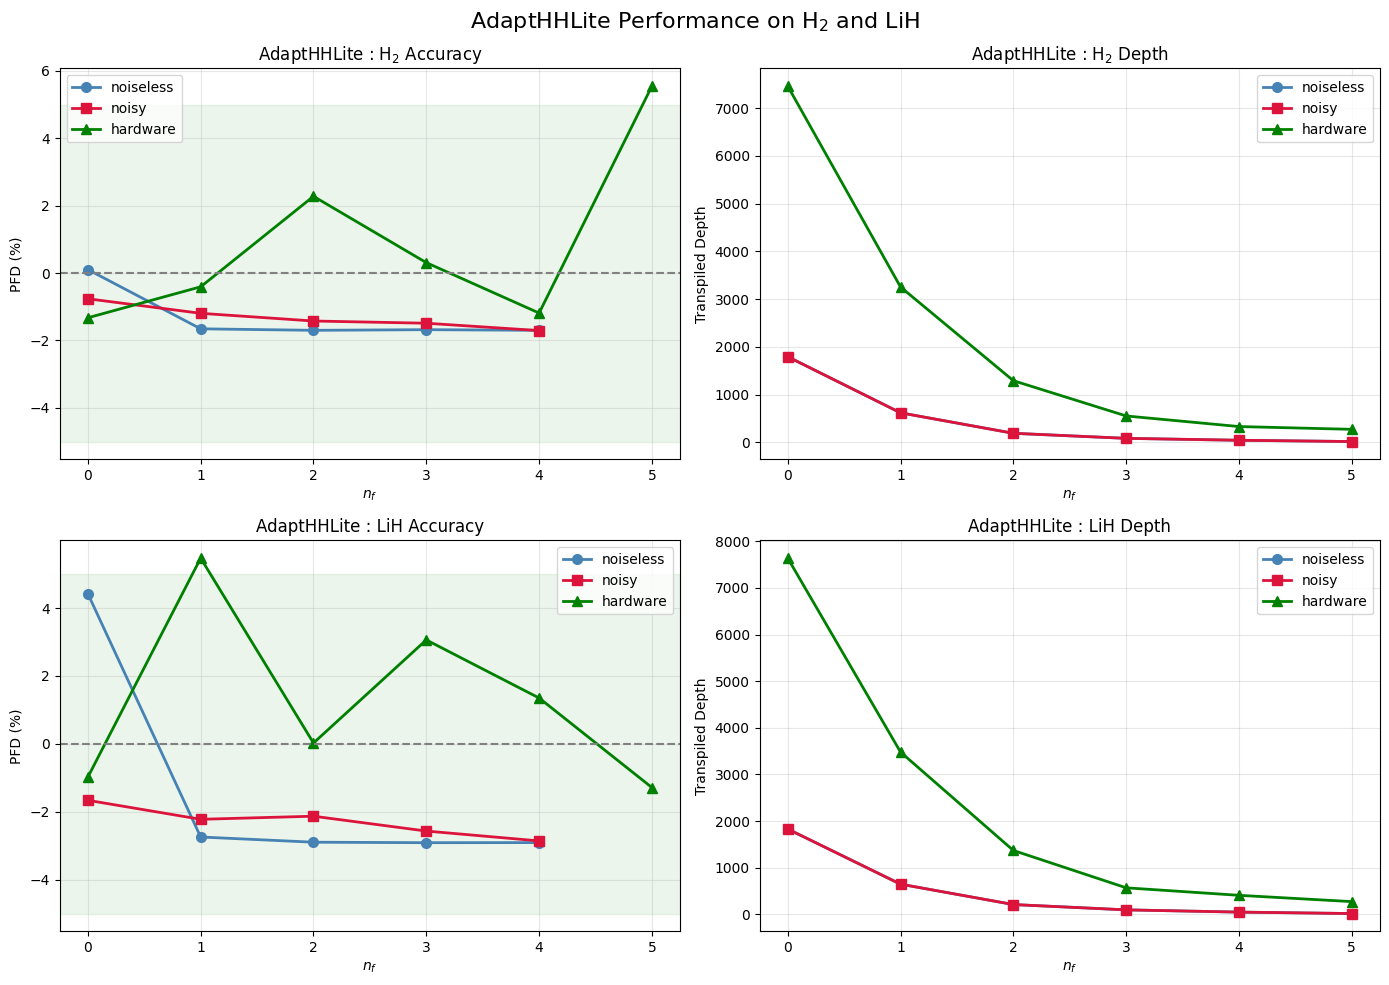

In [ ]:


fig, axes = plt.subplots(
    2, 2,
    figsize=(14,10)
)



colors = {
    'noiseless': 'steelblue',
    'noisy': 'crimson',
    'hardware': 'green'
}

markers = {
    'noiseless': 'o',
    'noisy': 's',
    'hardware': '^'
}



ax = axes[0,0]

for mode, res in adapt_results_H2.items():

    nf_arr  = np.array([r[0] for r in res])
    pfd_arr = np.array([r[3] for r in res])

    valid = ~np.isnan(pfd_arr)

    ax.plot(
        nf_arr[valid],
        pfd_arr[valid],
        marker=markers[mode],
        linewidth=2,
        markersize=7,
        color=colors[mode],
        label=mode
    )

ax.axhline(
    0,
    linestyle='--',
    color='gray'
)

ax.axhspan(
    -5,
    5,
    alpha=0.08,
    color='green'
)

ax.set_title("AdaptHHLite : H$_2$ Accuracy")
ax.set_xlabel(r"$n_f$")
ax.set_ylabel("PFD (%)")
ax.grid(alpha=0.3)
ax.legend()


ax = axes[0,1]

for mode, res in adapt_results_H2.items():

    nf_arr = np.array([r[0] for r in res])
    d_arr  = np.array([r[4] for r in res])

    ax.plot(
        nf_arr,
        d_arr,
        marker=markers[mode],
        linewidth=2,
        markersize=7,
        color=colors[mode],
        label=mode
    )

ax.set_title("AdaptHHLite : H$_2$ Depth")
ax.set_xlabel(r"$n_f$")
ax.set_ylabel("Transpiled Depth")
ax.grid(alpha=0.3)
ax.legend()



ax = axes[1,0]

for mode, res in adapt_results_LiH.items():

    nf_arr  = np.array([r[0] for r in res])
    pfd_arr = np.array([r[3] for r in res])

    valid = ~np.isnan(pfd_arr)

    ax.plot(
        nf_arr[valid],
        pfd_arr[valid],
        marker=markers[mode],
        linewidth=2,
        markersize=7,
        color=colors[mode],
        label=mode
    )

ax.axhline(
    0,
    linestyle='--',
    color='gray'
)

ax.axhspan(
    -5,
    5,
    alpha=0.08,
    color='green'
)

ax.set_title("AdaptHHLite : LiH Accuracy")
ax.set_xlabel(r"$n_f$")
ax.set_ylabel("PFD (%)")
ax.grid(alpha=0.3)
ax.legend()



ax = axes[1,1]

for mode, res in adapt_results_LiH.items():

    nf_arr = np.array([r[0] for r in res])
    d_arr  = np.array([r[4] for r in res])

    ax.plot(
        nf_arr,
        d_arr,
        marker=markers[mode],
        linewidth=2,
        markersize=7,
        color=colors[mode],
        label=mode
    )

ax.set_title("AdaptHHLite : LiH Depth")
ax.set_xlabel(r"$n_f$")
ax.set_ylabel("Transpiled Depth")
ax.grid(alpha=0.3)
ax.legend()


plt.suptitle(
    "AdaptHHLite Performance on H$_2$ and LiH",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "adapthhllite_results.png",
    dpi=250
)

plt.show()